# Proyek Klasifikasi Gambar: [Animals-10]
- **Nama:** Sintiya Risla Miftaqul Nikmah
- **Email:** apc284d6x0246@student.devacademy.id
- **ID Dicoding:** APC284D6X0246

## Import Semua Packages/Library yang Digunakan


In [12]:
import os
import shutil
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import tensorflowjs as tfjs
import random

## Data Preparation

### Data Loading

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animals10' dataset.
Path to dataset files: /kaggle/input/animals10


In [13]:
data = "/kaggle/input/animals10/raw-img"
path = "/kaggle/working/raw-img"

if not os.path.exists(path):
    shutil.copytree(data, path)
    print("Dataset copied to working directory.")
else:
    print("Dataset already exists in working directory.")


root = "/kaggle/working/raw-img"


translate = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}


for folder in os.listdir(root):
    old_path = os.path.join(root, folder)
    if not os.path.isdir(old_path):
        continue

    if folder in translate:
        new_name = translate[folder]
        new_path = os.path.join(root, new_name)

        print(f"Renaming: {folder} → {new_name}")
        os.rename(old_path, new_path)
    else:
        print(f"Skipping (no translation): {folder}")


Dataset copied to working directory.
Renaming: elefante → elephant
Renaming: scoiattolo → squirrel
Renaming: gallina → chicken
Renaming: ragno → spider
Renaming: gatto → cat
Renaming: pecora → sheep
Renaming: cane → dog
Renaming: mucca → cow
Renaming: cavallo → horse
Renaming: farfalla → butterfly


In [14]:
root = "/kaggle/working/raw-img"

for folder in os.listdir(root):
    folder_path = os.path.join(root, folder)

    if not os.path.isdir(folder_path):
        continue

    num_files = len([
        f for f in os.listdir(folder_path)
        if os.path.isfile(os.path.join(folder_path, f))
    ])

    print(f"{folder}: {num_files} images")


dog: 4863 images
sheep: 1820 images
spider: 4821 images
elephant: 1446 images
cow: 1866 images
cat: 1668 images
horse: 2623 images
squirrel: 1862 images
butterfly: 2112 images
chicken: 3098 images


In [15]:
root = "/kaggle/working/raw-img"
allowed = {"dog", "spider", "chicken"}

for folder in os.listdir(root):
    folder_path = os.path.join(root, folder)

    if not os.path.isdir(folder_path):
        continue

    if folder not in allowed:
        print(f"Deleting folder: {folder}")
        shutil.rmtree(folder_path)
    else:
        print(f"Keeping folder: {folder}")


Keeping folder: dog
Deleting folder: sheep
Keeping folder: spider
Deleting folder: elephant
Deleting folder: cow
Deleting folder: cat
Deleting folder: horse
Deleting folder: squirrel
Deleting folder: butterfly
Keeping folder: chicken


In [16]:
path = "/kaggle/working/raw-img"
classes = ["dog", "spider", "chicken"]

X = []
y = []

for label, class_name in enumerate(classes):
    class_path = os.path.join(path, class_name)

    for filename in os.listdir(class_path):
        img_path = os.path.join(class_path, filename)

        img = cv2.imread(img_path)

        if img is None:
            print("Skipping unreadable file:", img_path)
            continue

        X.append(img)
        y.append(label)

X = np.array(X, dtype=object)
y = np.array(y)

print("Total gambar :", len(X))
print("Class distribution:",
      {cls: sum(y == i) for i, cls in enumerate(classes)})



Total gambar : 12782
Class distribution: {'dog': np.int64(4863), 'spider': np.int64(4821), 'chicken': np.int64(3098)}


### Data Preprocessing

#### Split Dataset

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("\nDataset Split:")
print("Train :", len(X_train))
print("Val   :", len(X_val))
print("Test  :", len(X_test))


Dataset Split:
Train : 8947
Val   : 1917
Test  : 1918


## Modelling

In [18]:
img_size = (128, 128)
num_class = 3

def resize_images(X):
    X_resized = []
    for img in X:
        resized = tf.image.resize(img, img_size)
        X_resized.append(resized)
    return tf.stack(X_resized)

X_train_resized = resize_images(X_train) / 255.0
X_val_resized   = resize_images(X_val)   / 255.0
X_test_resized  = resize_images(X_test)  / 255.0


datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)
datagen.fit(X_train_resized)



model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_size[0], img_size[1], 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    # Block 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    # Block 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    # Block 4
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_class, activation='softmax')
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,585,667 (17.49 MB)

 Trainable params: 4,584,707 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [19]:
history = model.fit(
    datagen.flow(X_train_resized, y_train, batch_size=32),
    validation_data=(X_val_resized, y_val),
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 724s 3s/step - accuracy: 0.5822 - loss: 1.4621 - val_accuracy: 0.6270 - val_loss: 1.3187 - learning_rate: 3.0000e-04
Epoch 2/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 708s 3s/step - accuracy: 0.7811 - loss: 0.5614 - val_accuracy: 0.8331 - val_loss: 0.4281 - learning_rate: 3.0000e-04
Epoch 3/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 738s 3s/step - accuracy: 0.8254 - loss: 0.4631 - val_accuracy: 0.8237 - val_loss: 0.4661 - learning_rate: 3.0000e-04
Epoch 4/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 716s 3s/step - accuracy: 0.8418 - loss: 0.4124 - val_accuracy: 0.6985 - val_loss: 0.7226 - learning_rate: 3.0000e-04
Epoch 5/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 693s 2s/step - accuracy: 0.8646 - loss: 0.3633 - val_accuracy: 0.8211 - val_loss: 0.4496 - learning_rate: 3.0000e-04
Epoch 6/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 699s 2s/step - accuracy: 0.8864 - loss: 0.3035 - val_accuracy: 0.8748 - val_loss: 0.3260 - learning_rate: 6.0000e-05
Epoch 7/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 705s 3s/step - acc

## Evaluasi dan Visualisasi

In [20]:
train_loss, train_acc = model.evaluate(X_train_resized, y_train)
print("Train Accuracy:", train_acc)
print("Train Loss:", train_loss)

test_loss, test_acc = model.evaluate(X_test_resized, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


280/280 ━━━━━━━━━━━━━━━━━━━━ 141s 504ms/step - accuracy: 0.9021 - loss: 0.2526
Train Accuracy: 0.9023136496543884
Train Loss: 0.25749072432518005
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 505ms/step - accuracy: 0.8635 - loss: 0.3508
Test Accuracy: 0.865484893321991
Test Loss: 0.34523797035217285


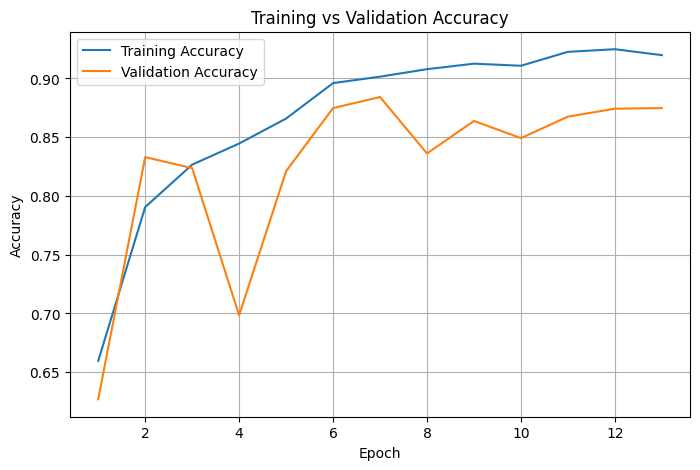

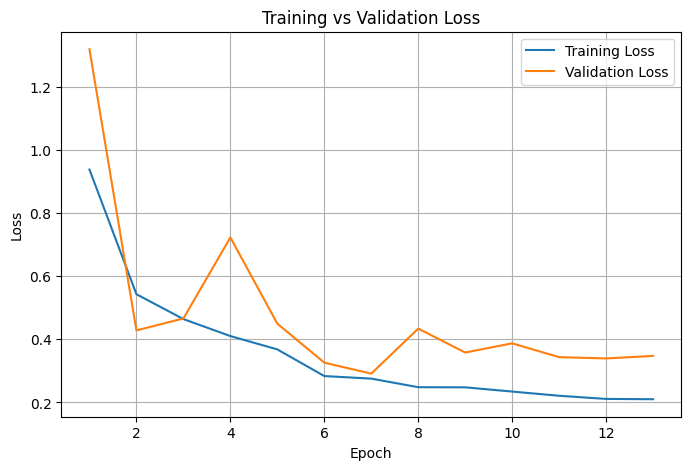

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


## Konversi Model

In [22]:
class_names = ["chicken", "dog", "spider"]

savedmodel_path = "saved_model"
model.export(savedmodel_path)
print("SavedModel berhasil disimpan ke folder:", savedmodel_path)


tflite_dir = "tflite"
os.makedirs(tflite_dir, exist_ok=True)
tflite_path = os.path.join(tflite_dir, "model.tflite")
converter = tf.lite.TFLiteConverter.from_saved_model(savedmodel_path)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print("TF-Lite berhasil disimpan sebagai:", tflite_path)
label_path = os.path.join(tflite_dir, "label.txt")
with open(label_path, "w") as f:
    f.write("\n".join(class_names))
print("Label berhasil disimpan ke:", label_path)


save_path = "tfjs_model"
tfjs.converters.save_keras_model(model, save_path)
print("Model TFJS berhasil disimpan ke:", save_path)

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135737419745424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135737419747728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135737419748880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135737419748688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135737419746768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135737419749264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135737419747152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135737419746960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135737419750608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135737419750800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135737419750032: Te

TF-Lite berhasil disimpan sebagai: tflite/model.tflite
Label berhasil disimpan ke: tflite/label.txt
failed to lookup keras version from the file,
    this is likely a weight only file
Model TFJS berhasil disimpan ke: tfjs_model


## Inference (Optional)

In [24]:
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
class_names = ["chicken", "dog", "spider"]

idx = random.randint(0, len(X_test_resized) - 1)

test_img = X_test_resized[idx]
true_label = y_test[idx]

input_data = np.expand_dims(test_img, axis=0).astype(np.float32)

interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

output_data = interpreter.get_tensor(output_details[0]['index'])
pred_class = np.argmax(output_data)

print("Index gambar:", idx)
print("Prediksi     :", class_names[pred_class])
print("Label Asli   :", class_names[true_label])

Index gambar: 635
Prediksi     : chicken
Label Asli   : chicken


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [27]:
!zip -r saved_model.zip saved_model/

  adding: saved_model/ (stored 0%)
  adding: saved_model/variables/ (stored 0%)
  adding: saved_model/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: saved_model/variables/variables.index (deflated 70%)
  adding: saved_model/assets/ (stored 0%)
  adding: saved_model/fingerprint.pb (stored 0%)
  adding: saved_model/saved_model.pb (deflated 87%)
